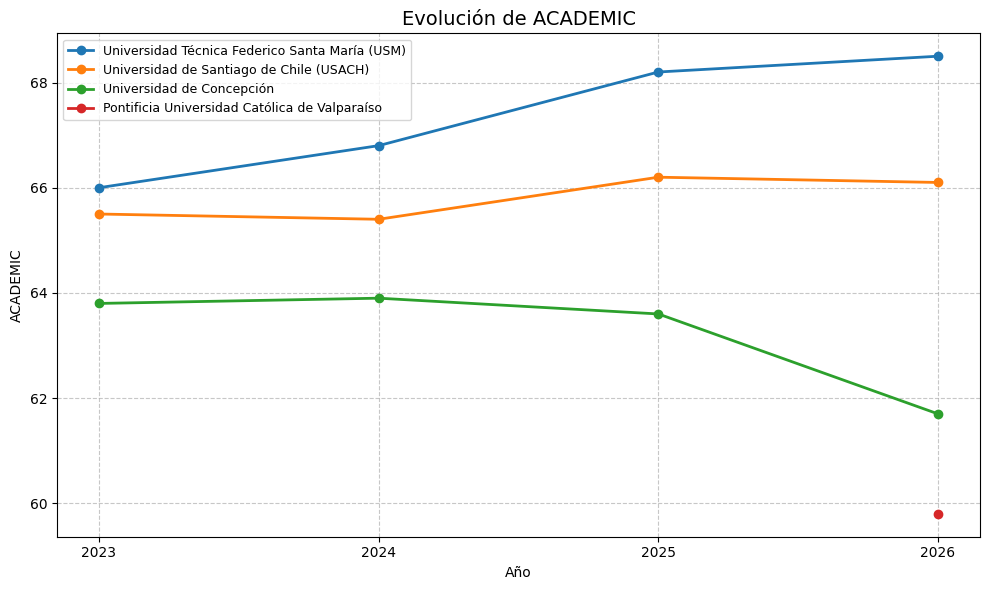

Guardado: evolucion_academic.png (Y: 59.4 – 68.9)


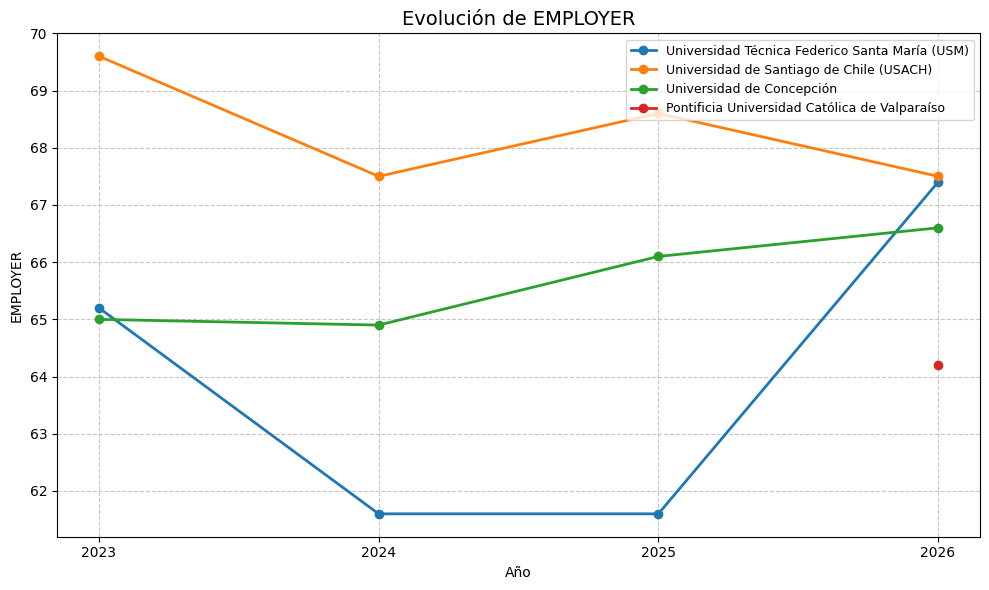

Guardado: evolucion_employer.png (Y: 61.2 – 70.0)


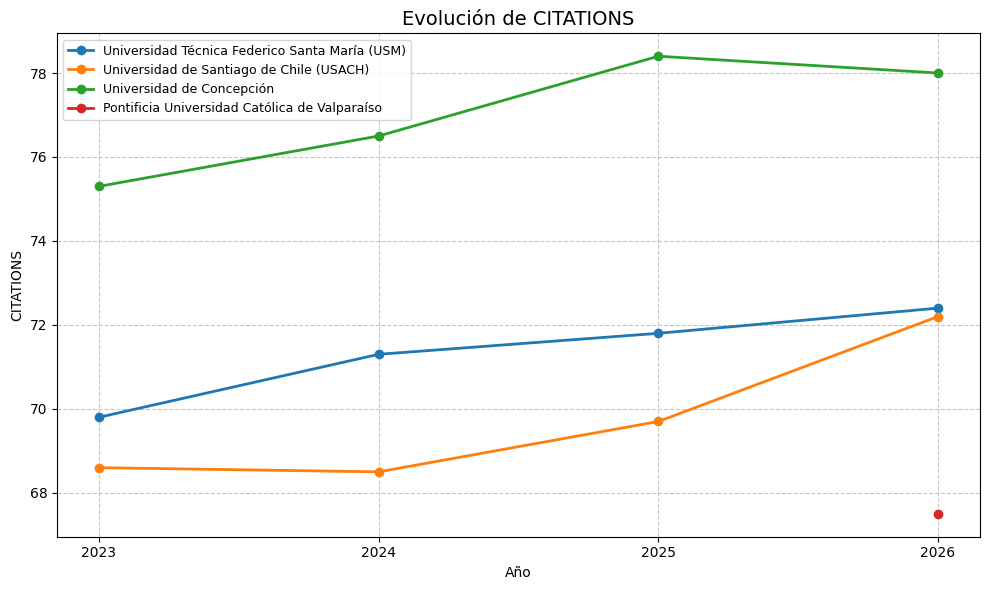

Guardado: evolucion_citations.png (Y: 67.0 – 78.9)


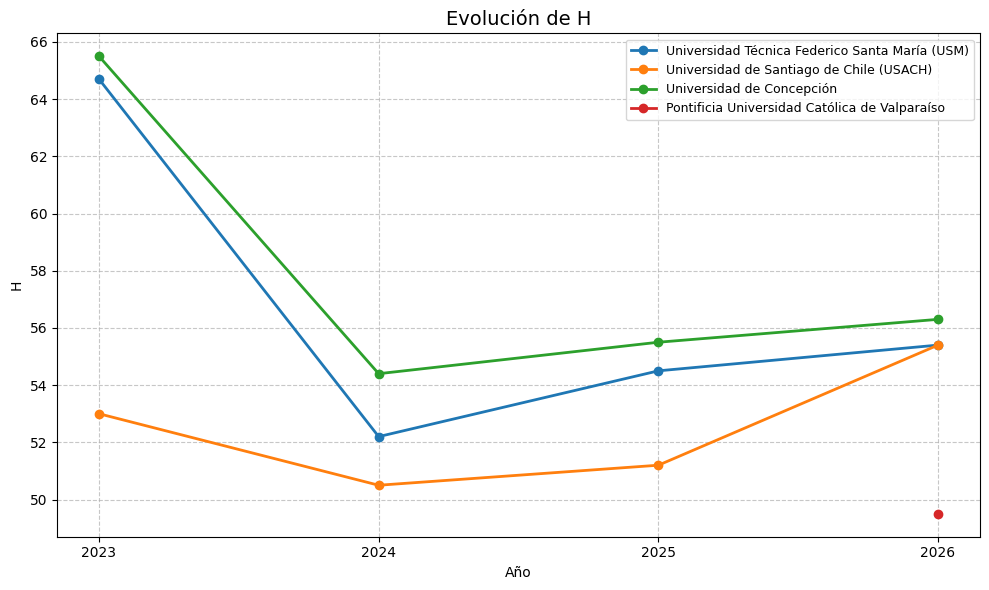

Guardado: evolucion_h.png (Y: 48.7 – 66.3)


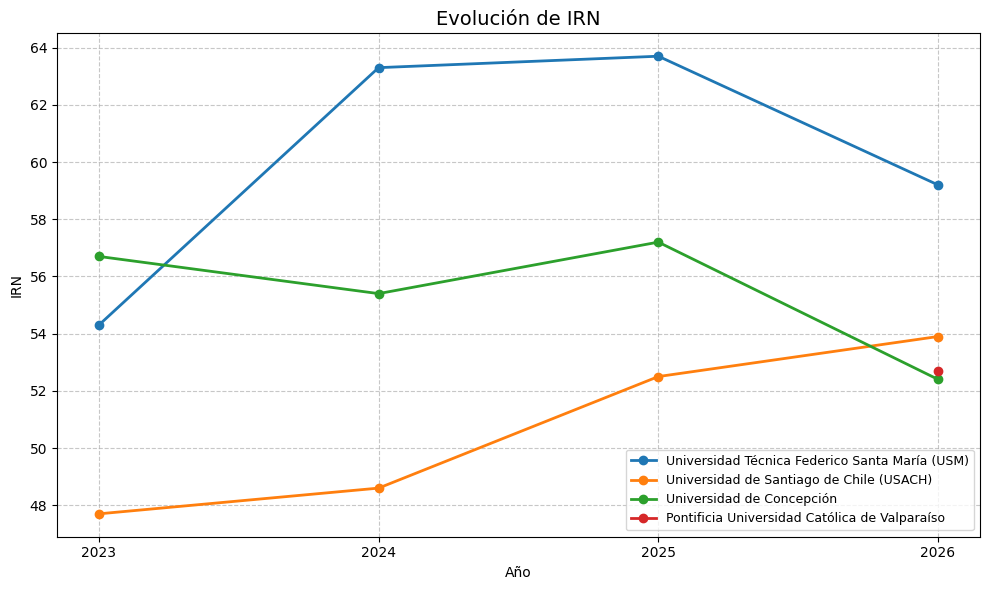

Guardado: evolucion_irn.png (Y: 46.9 – 64.5)


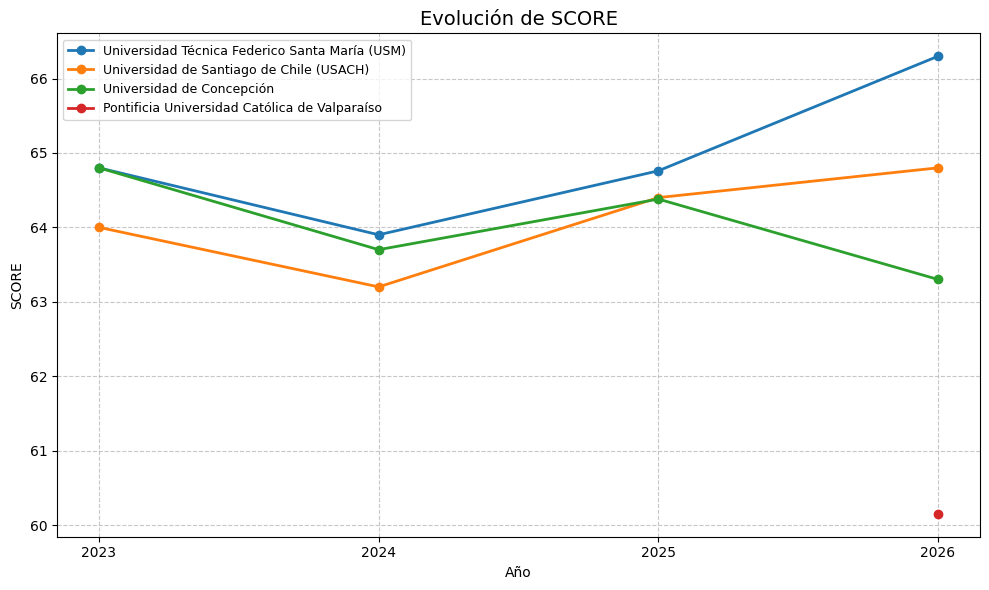

Guardado: evolucion_score.png (Y: 59.8 – 66.6)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar datos
df = pd.read_csv('QS_Ing_datosChile.csv')

# Definir métricas
metricas = ['ACADEMIC', 'EMPLOYER', 'CITATIONS', 'H', 'IRN', 'SCORE']

# Obtener universidades y paleta de colores consistente
universidades = df['INSTITUTION'].unique()
paleta = sns.color_palette('tab10', n_colors=len(universidades))
colores = dict(zip(universidades, paleta))

for metrica in metricas:
    plt.figure(figsize=(10, 6))

    # Calcular rango de valores de la métrica (sin considerar NaN)
    valores = df[metrica].dropna()
    min_val = valores.min()
    max_val = valores.max()
    # Agregar un pequeño margen (5% del rango)
    margin = (max_val - min_val) * 0.05
    y_low = max(0, min_val - margin)   # no bajar de 0
    y_high = min(100, max_val + margin) # no subir de 100

    for uni in universidades:
        datos_uni = df[df['INSTITUTION'] == uni].sort_values('AÑO')
        plt.plot(datos_uni['AÑO'], datos_uni[metrica],
                 marker='o', linestyle='-', linewidth=2,
                 label=uni, color=colores[uni])

    plt.title(f'Evolución de {metrica}', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel(metrica)
    plt.ylim(y_low, y_high)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(sorted(df['AÑO'].unique()))
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()

    nombre_archivo = f'evolucion_{metrica.lower()}.png'
    plt.savefig(nombre_archivo, dpi=300)
    plt.show()
    print(f'Guardado: {nombre_archivo} (Y: {y_low:.1f} – {y_high:.1f})')